# TP5 — Optimisation numérique dans DICE

**Séance du 16 septembre 2026 — M2 Actuariat, Sorbonne Université**

Ce notebook traite de la tarification du carbone et du contrôle optimal. Nous passons des scénarios — ce qui pourrait arriver — au problème du planificateur social — ce qui devrait arriver — puis calculons numériquement le coût social du carbone (CSC).

**Fichier de modèle :** le notebook charge `toolbox/DICE.py`, fourni avec la séance.

**Programme**
1. Charger le modèle et examiner les états et les contrôles.
2. Définir l’objectif du planificateur et l’approximation à horizon fini.
3. Résoudre le modèle avec une fenêtre glissante et lire le CSC.
4. Étudier la sensibilité aux dommages et exporter les résultats.


## 1) Préparation : installer les dépendances et charger DICE

Exécutez la cellule de préparation, puis les cellules suivantes. Les paquets pip manquants sont installés ; `DICE.py` est fourni dans `toolbox/`.


In [1]:
# Préparation commune des TP Python
# Le notebook utilise uniquement les ressources fournies dans le dossier codes/.
from pathlib import Path
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib', 'scipy': 'scipy', 'numba': 'numba', 'tqdm': 'tqdm'}
missing = [package for module, package in REQUIRED_PACKAGES.items()
           if importlib.util.find_spec(module) is None]
if missing:
    print("Installation des paquets manquants :", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

WORKDIR = Path.cwd().resolve()
CODES_DIR = WORKDIR.parent if WORKDIR.name == "correction" else WORKDIR
TOOLBOX_DIR = CODES_DIR / "toolbox"
DATA_DIR = CODES_DIR / "data"
if not CODES_DIR.is_dir():
    raise FileNotFoundError("Exécutez le notebook depuis le dossier codes/." )
if TOOLBOX_DIR.is_dir():
    sys.path.insert(0, str(TOOLBOX_DIR))

DICE_FILE = TOOLBOX_DIR / "DICE.py"
if not DICE_FILE.is_file():
    raise FileNotFoundError(
        f"Module du cours introuvable : {DICE_FILE}. "
        "Téléchargez le dossier codes complet, avec toolbox/."
    )

print("Environnement prêt :", CODES_DIR)


Environnement Python et module DICE prêts.


In [2]:
import importlib.util

if importlib.util.find_spec("DICE") is None:
    raise ModuleNotFoundError(
        "DICE.py est introuvable. Réexécutez la cellule de préparation."
    )

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from DICE import (
    Params,
    init_states,
    update_path,
    mat_to_df,
    obj_fun,
    run_optimal_policy,
)

p = Params()
print("Paramètres DICE chargés ; nombre de périodes :", p.nT)


Paramètres DICE chargés ; nombre de périodes : 18


## 2) Structure du modèle

- **États :** capital $K_t$, productivité $A_t$, population $L_t$, stocks de carbone $M_t^{AT},M_t^{UP},M_t^{LO}$ et températures $T_t^{AT},T_t^{LO}$.
- **Contrôles :** taux d’épargne $s_t$ et taux de réduction des émissions $\mu_t$ ; ce dernier détermine implicitement le prix du carbone.
- **Unités :** $C_t$ est en milliers de milliards de dollars et $L_t$ en millions d’habitants, donc $c_t=1000C_t/L_t$ est en milliers de dollars par habitant.


In [3]:

# Paramètres instantanés et construire un chemin initial
p = Params()
sim = init_states(p)

# Contrôles de référence pour l'initialisation (pas optimaux): petite réduction, économie constante
sim[:, p.i_mu] = 0.03
sim[:, p.i_s]  = 0.20

# Mise à jour du chemin pour toutes les variables endogènes compte tenu des contrôles
timevec = range(1, p.nT)
sim = update_path(sim, timevec, p)

# Peek at available columns
print("Columns:", p.col)
print("Longueur de l’horizon (périodes) :", p.nT, " — années:", sim[-1, p.i_time])


Columns: ['time', 'A', 's', 'Y', 'Q', 'C', 'K', 'L', 'sigma', 'theta1', 'mu', 'E', 'F', 'T_AT', 'T_LO', 'E_land', 'F_EX', 'M_AT', 'M_UP', 'M_LO', 'Tax']
Longueur de l’horizon (périodes) : 18  — années: 2100.0


## 3) Objectif du planificateur

Nous maximisons le bien-être social actualisé
$$
W=\sum_{i=0}^{I^\star}\beta_\Delta^iL_{t+i\Delta}u\!\left(1000\frac{C_{t+i\Delta}}{L_{t+i\Delta}}\right),\qquad \beta_\Delta=(1+\rho)^{-\Delta},
$$
avec une utilité CRRA $u(c)=(c^{1-\gamma}-1)/(1-\gamma)$. Le module fournit la fonction `obj_fun`.

L’horizon infini est remplacé par un horizon fini $I^\star$ dont la contribution résiduelle est inférieure à une tolérance.


In [4]:

# Examiner l'objectif sur un chemin de contrôle constant (contrôle de la sanité)
# Ici, nous 'flattons' un contrôle (par exemple, l'épargne seulement) et évaluons le bien-être.
x_const = np.full(p.nT-1, 0.20)  # constant saving
W_val = obj_fun(x_const, sim, timevec, p, [p.i_s])
print("Objective value (negative welfare) on constant s=0.20 path:", W_val)


Objective value (negative welfare) on constant s=0.20 path: -173569.0673395565


## 4) Fenêtre de planification à horizon fini $I^\star$

La fenêtre est choisie de façon que le poids d’actualisation du dernier terme soit inférieur à `p.toly`.


In [5]:

# Calculer une fenêtre de planification analogue à celle de DICE.run_optimal_policy
disc, Tplanner = 1.0, 1
while disc > p.toly:
    Tplanner += 1
    disc *= (1.0/(1.0 + p.rho))**p.Delta

print("Fenêtre de planification retenue (périodes) :", Tplanner, " (each period = Δ années =", p.Delta, ")")


Fenêtre de planification retenue (périodes) : 94  (each period = Δ années = 5 )


## 5) Premier problème : optimiser seulement l’épargne

Nous optimisons $s_t$ dans ses bornes et maintenons $\mu_t$ constant. Cette solution constitue la référence sans transition.


In [6]:

print("Résolution : trajectoire optimale de l’épargne...")
bounds_s   = (p.s_lower, p.s_upper)
control_id = [p.i_s]
path_opt_s = run_optimal_policy(sim.copy(), timevec, p, bounds_s, control_id)

print("Done. Preview of s_t path (first 5):", path_opt_s[:5, p.i_s])


Résolution : trajectoire optimale de l’épargne...


Optimizing:   0%|          | 0/17 [00:00<?, ?it/s]

Optimizing:   6%|▌         | 1/17 [00:00<00:11,  1.45it/s]

Optimizing:  12%|█▏        | 2/17 [00:01<00:09,  1.54it/s]

Optimizing:  18%|█▊        | 3/17 [00:01<00:08,  1.63it/s]

...

Optimizing:  88%|████████▊ | 15/17 [00:07<00:00,  2.44it/s]

Optimizing:  94%|█████████▍| 16/17 [00:08<00:00,  2.33it/s]

Optimizing: 100%|██████████| 17/17 [00:08<00:00,  2.26it/s]

Optimizing: 100%|██████████| 17/17 [00:08<00:00,  1.93it/s]

Done. Preview of s_t path (first 5): [0.2        0.26397465 0.25815643 0.25382203 0.25077345]


## 6) Optimiser l’épargne et la réduction des émissions

Nous optimisons maintenant $(s_t,\mu_t)$. Le prix implicite du carbone est stocké dans la colonne `Tax`.


In [7]:

print("Résolution : trajectoire optimale jointe de (s_t, μ_t)...")
bounds_smu   = [(p.s_lower, p.s_upper), (0.0, 1.0)]
control_id   = [p.i_s, p.i_mu]
path_opt_smu = run_optimal_policy(sim.copy(), timevec, p, bounds_smu, control_id)

print("Done. Preview of μ_t path (first 5):", path_opt_smu[:5, p.i_mu])


Résolution : trajectoire optimale jointe de (s_t, μ_t)...


Optimizing:   0%|          | 0/17 [00:00<?, ?it/s]

Optimizing:   6%|▌         | 1/17 [00:06<01:46,  6.66s/it]

Optimizing:  12%|█▏        | 2/17 [00:07<00:49,  3.33s/it]

Optimizing:  18%|█▊        | 3/17 [00:08<00:32,  2.29s/it]

...

Optimizing:  88%|████████▊ | 15/17 [00:25<00:03,  1.72s/it]

Optimizing:  94%|█████████▍| 16/17 [00:26<00:01,  1.53s/it]

Optimizing: 100%|██████████| 17/17 [00:26<00:00,  1.28s/it]

Optimizing: 100%|██████████| 17/17 [00:26<00:00,  1.58s/it]

Done. Preview of μ_t path (first 5): [0.03       0.16101647 0.18519147 0.21005311 0.23478373]


## 7) Visualiser les contrôles et le prix du carbone

Tracez séparément l’épargne optimale $s_t$, le taux de réduction $\mu_t$ et le prix implicite du carbone `Tax`, en USD/tCO₂.


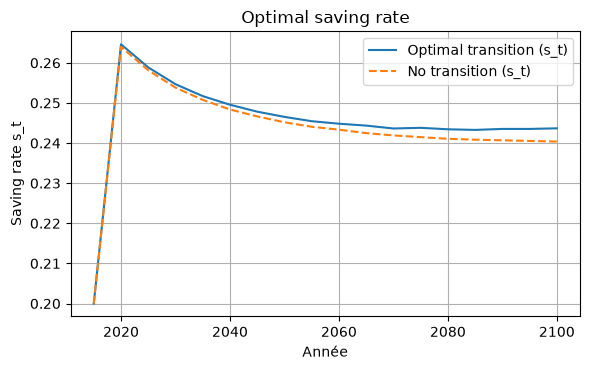

In [8]:
# Taux d'épargne du lot
plt.figure(figsize=(6,3.8))
plt.plot(path_opt_smu[:, p.i_time], path_opt_smu[:, p.i_s], label="Optimal transition (s_t)")
plt.plot(path_opt_s[:,  p.i_time], path_opt_s[:,  p.i_s],  linestyle="--", label="No transition (s_t)")
plt.xlabel("Année"); plt.ylabel("Saving rate s_t"); plt.title("Optimal saving rate")
plt.legend(); plt.grid(True); plt.tight_layout()


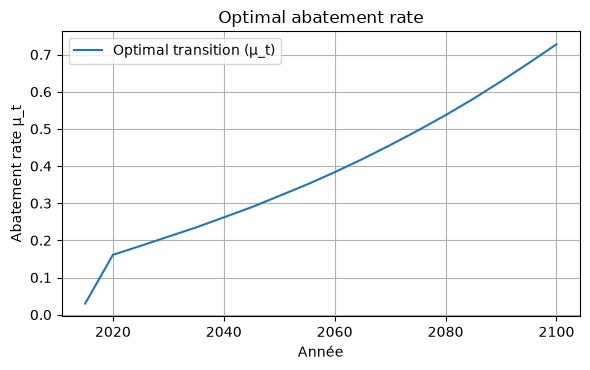

In [9]:
# Taux de réduction des parcelles
plt.figure(figsize=(6,3.8))
plt.plot(path_opt_smu[:, p.i_time], path_opt_smu[:, p.i_mu], label="Optimal transition (μ_t)")
plt.xlabel("Année"); plt.ylabel("Abatement rate μ_t"); plt.title("Optimal abatement rate")
plt.legend(); plt.grid(True); plt.tight_layout()


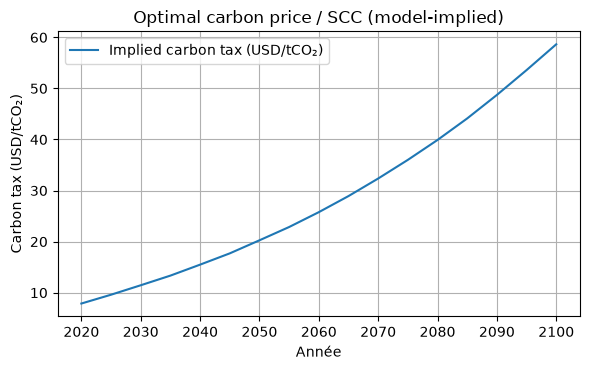

In [10]:
# Taxe sur le carbone implicite (USD par tCO2)
plt.figure(figsize=(6,3.8))
plt.plot(path_opt_smu[:, p.i_time], path_opt_smu[:, p.i_Tax], label="Implied carbon tax (USD/tCO₂)")
plt.xlabel("Année"); plt.ylabel("Carbon tax (USD/tCO₂)"); plt.title("Optimal carbon price / SCC (model-implied)")
plt.legend(); plt.grid(True); plt.tight_layout()


## 8) Lire le coût social du carbone

- La colonne `Tax` contient le prix optimal du carbone, en USD/tCO₂.
- Le CSC est le prix d’ombre des émissions dans le problème du planificateur. Il peut aussi être estimé par une petite perturbation des émissions puis conversion de la perte marginale de bien-être en dollars.

Le squelette ci-dessous illustre cette seconde méthode ; il reste commenté pour réduire le temps d’exécution.


In [11]:

# -- Optional: perturbation-based SCC at a chosen date (slow; left as a template) --
# t_idx = 10         # pick a period index
# eps = 1e-3 # ajouter 0,001 GtC (ajuster les unités au besoin) aux émissions à t idx
# 
# base = path_opt_smu.copy()
# pert = path_opt_smu.copy()
# 
# # Injecter une petite augmentation des émissions à t idx en réduisant la réduction d'un cran
# # (Ici comme une illustration; dans une expérience complète vous modifieriez E t directement ou ajouteriez au cycle du carbone)
# pert[t_idx, p.i_mu] = max(0.0, pert[t_idx, p.i_mu] - 1e-5)
# 
# base_W = obj_fun(np.hstack([base[1:, p.i_s], base[1:, p.i_mu]]), base, range(1, p.nT), p, [p.i_s, p.i_mu])
# pert_W = obj_fun(np.hstack([pert[1:, p.i_s], pert[1:, p.i_mu]]), pert, range(1, p.nT), p, [p.i_s, p.i_mu])
# dW = pert_W - base_W  # (negative welfare) difference
# print("ΔW de ε-perturbation:", dW)
# # Convertir en USD/tCO2 en utilisant l'utilitaire marginal à t idx si nécessaire.


## 9) Sensibilité à des dommages plus élevés

Modifiez la fonction de dommages avec `p.user_damage_fn`, puis relancez l’optimisation pour observer la réaction de $\mu_t$ et du prix du carbone.


Optimizing:   0%|          | 0/17 [00:00<?, ?it/s]

Optimizing:   6%|▌         | 1/17 [00:06<01:48,  6.79s/it]

Optimizing:  12%|█▏        | 2/17 [00:07<00:52,  3.48s/it]

Optimizing:  18%|█▊        | 3/17 [00:08<00:32,  2.30s/it]

Optimizing:  24%|██▎       | 4/17 [00:09<00:20,  1.61s/it]

...

Optimizing:  82%|████████▏ | 14/17 [00:21<00:03,  1.07s/it]

Optimizing:  88%|████████▊ | 15/17 [00:23<00:03,  1.61s/it]

Optimizing:  94%|█████████▍| 16/17 [00:24<00:01,  1.37s/it]

Optimizing: 100%|██████████| 17/17 [00:25<00:00,  1.25s/it]

Optimizing: 100%|██████████| 17/17 [00:25<00:00,  1.51s/it]

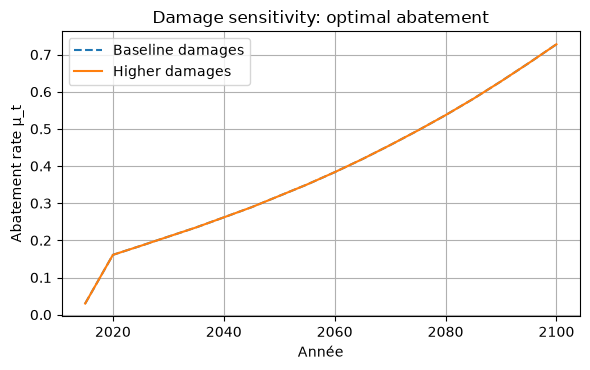

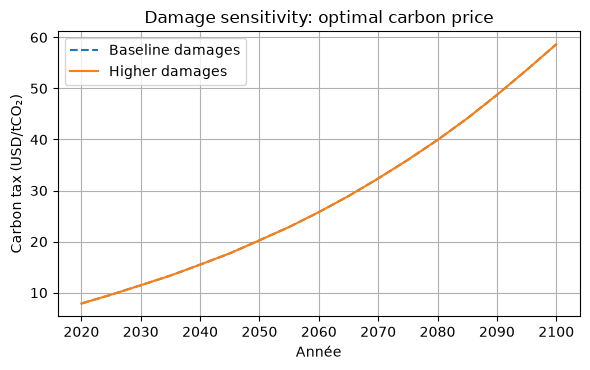

In [12]:

def higher_damage(T, p_local: Params):
    # Slightly steeper quadratic damages as an illustration
    return 0.0030 * (np.asarray(T) ** 2)

p_sens = Params()
sim_sens = init_states(p_sens)
sim_sens[:, p_sens.i_mu] = 0.03
sim_sens[:, p_sens.i_s]  = 0.20
sim_sens = update_path(sim_sens, range(1, p_sens.nT), p_sens)

p_sens.user_damage_fn = higher_damage
path_opt_smu_highDam = run_optimal_policy(sim_sens.copy(), range(1, p_sens.nT), p_sens, [(p_sens.s_lower,p_sens.s_upper),(0.0,1.0)], [p_sens.i_s, p_sens.i_mu])

# Comparaison par parcelle pour μ t
plt.figure(figsize=(6,3.8))
plt.plot(path_opt_smu[:, p.i_time], path_opt_smu[:, p.i_mu], linestyle="--", label="Baseline damages")
plt.plot(path_opt_smu_highDam[:, p.i_time], path_opt_smu_highDam[:, p.i_mu], label="Higher damages")
plt.xlabel("Année"); plt.ylabel("Abatement rate μ_t"); plt.title("Damage sensitivity: optimal abatement")
plt.legend(); plt.grid(True); plt.tight_layout()

# Comparaison par parcelle pour la taxe implicite sur le carbone
plt.figure(figsize=(6,3.8))
plt.plot(path_opt_smu[:, p.i_time], path_opt_smu[:, p.i_Tax], linestyle="--", label="Baseline damages")
plt.plot(path_opt_smu_highDam[:, p.i_time], path_opt_smu_highDam[:, p.i_Tax], label="Higher damages")
plt.xlabel("Année"); plt.ylabel("Carbon tax (USD/tCO₂)"); plt.title("Damage sensitivity: optimal carbon price")
plt.legend(); plt.grid(True); plt.tight_layout()


## 10) Exporter les résultats

Convertissez les tableaux en `DataFrame` pour poursuivre l’analyse ou produire d’autres graphiques.


In [13]:

df_baseline = pd.DataFrame({
    "year": path_opt_smu[:, p.i_time],
    "s":    path_opt_smu[:, p.i_s],
    "mu":   path_opt_smu[:, p.i_mu],
    "tax":  path_opt_smu[:, p.i_Tax],
    "E":    path_opt_smu[:, p.i_E],
    "T_AT": path_opt_smu[:, p.i_T_AT],
    "C":    path_opt_smu[:, p.i_C],
})
df_baseline.head()


,year,s,mu,tax,E,T_AT,C
0,2015.0,0.200000,0.030000,NaN,NaN,0.850000,NaN
1,2020.0,0.264623,0.161016,7.872059,170.725556,0.989258,428.874227
2,2025.0,0.258865,0.185191,9.600504,181.811014,1.135512,517.220239
3,2030.0,0.254679,0.210053,11.450691,189.775618,1.287820,609.125900
4,2035.0,0.251709,0.234784,13.340697,195.430577,1.445025,705.631734


### Conclusion

- Le prix optimal `Tax` constitue la recommandation normative du modèle.
- La fenêtre finie met en œuvre la troncation temporelle.
- La résolution par fenêtre glissante produit les trajectoires complètes des états et des contrôles.
- Les hypothèses de dommages modifient directement $\mu_t$ et le prix implicite du carbone.
